#

In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the libraries for a $k$-NN.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from matplotlib.colors import ListedColormap

Creating a synthetic classification dataset and normalizing the
features.

In [3]:
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X[:, 0] = X[:, 0] * 1000

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Creating and fitting one model with $k=1$, one with $k=3$ and one with
$k=15$.

In [7]:
knn_1 = KNeighborsClassifier(n_neighbors=1).fit(X_train_scaled, y_train)
knn_3 = KNeighborsClassifier(n_neighbors=3).fit(X_train_scaled, y_train)
knn_15 = KNeighborsClassifier(n_neighbors=15).fit(X_train_scaled, y_train)

Plotting the decision boundaries of each model.

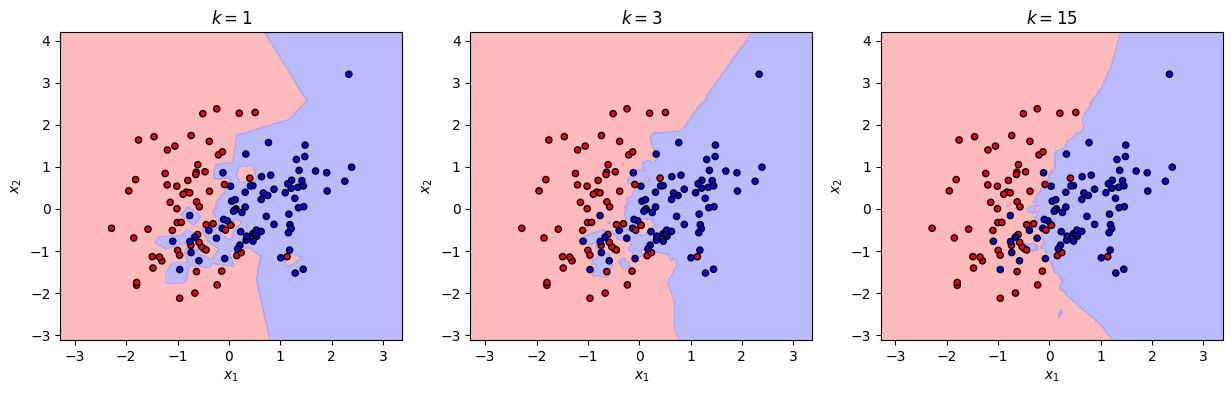

In [11]:
def plot_decision_boundary(model, X, y, ax, title):
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_ylabel(r"$x_2$")
    ax.set_xlabel(r"$x_1$")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_decision_boundary(knn_1, X_train_scaled, y_train, axes[0], r"$k=1$")
plot_decision_boundary(knn_3, X_train_scaled, y_train, axes[1], r"$k=3$")
plot_decision_boundary(knn_15, X_train_scaled, y_train, axes[2], r"$k=15$")

plt.show()

Printing the classifications reports of each model.

In [20]:
y_pred_1 = knn_1.predict(X_test_scaled)
y_pred_3 = knn_3.predict(X_test_scaled)
y_pred_15 = knn_15.predict(X_test_scaled)

rep_1 = classification_report(y_test, y_pred_1)
rep_3 = classification_report(y_test, y_pred_3)
rep_15 = classification_report(y_test, y_pred_15)

print("k=1")
print(rep_1)
print(60*"=")
print("k=3")
print(rep_3)
print(60*"=")
print("k=15")
print(rep_15)
print(60*"=")

k=1
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        34
           1       0.73      0.73      0.73        26

    accuracy                           0.77        60
   macro avg       0.76      0.76      0.76        60
weighted avg       0.77      0.77      0.77        60

k=3
              precision    recall  f1-score   support

           0       0.86      0.91      0.89        34
           1       0.88      0.81      0.84        26

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60

k=15
              precision    recall  f1-score   support

           0       0.93      0.79      0.86        34
           1       0.77      0.92      0.84        26

    accuracy                           0.85        60
   macro avg       0.85      0.86      0.85        60
weighted avg       0.86      0.85      0.85        60


As it was shown in the decision boundaries and performance reports,
small values of $k$ lead to overfitting, while larger ones might not be
a good represention of the neighborhood of the observations – showing
the importance of adjusting this HP.